In [1]:
from IPython.display import display, HTML
from tqdm.notebook import tqdm
import subprocess

# --- Phase 1: Lightweight packages ---
phase1 = [
    "scikit-learn==1.5.2",
    "tabpfn",
    "catboost",
    "xgboost",
    "lightgbm",
    "datasets",
    "ucimlrepo",
    "ace_tools"
]

# --- Phase 2: Heavy or Git-based packages ---
phase2 = [
    "autogluon==0.8.2 --no-cache-dir --upgrade",
    "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"
]

# --- Function to install packages with live output ---
def install_packages(package_list, phase_name):
    logs = []
    display(HTML(f"<h3>🚀 Starting {phase_name}</h3>"))
    for pkg in tqdm(package_list, desc=f"{phase_name}", unit="pkg"):
        display(HTML(f"<b>Installing:</b> {pkg}"))
        process = subprocess.Popen(
            ["pip", "install", "--no-cache-dir", "--upgrade", pkg],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )
        output = ""
        for line in process.stdout:
            output += line
        process.wait()
        logs.append(f"📦 {pkg}\n{output}")
    return logs

# --- Run both phases ---
logs_phase1 = install_packages(phase1, "Phase 1: Core Packages")
logs_phase2 = install_packages(phase2, "Phase 2: Heavy/Git Packages")

# --- Display combined logs ---
all_logs = logs_phase1 + logs_phase2
scrollable_logs = (
    "<pre style='max-height: 400px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px;'>"
    + "\n\n".join(all_logs) + "</pre>"
)
display(HTML(scrollable_logs))

Phase 1: Core Packages:   0%|          | 0/8 [00:00<?, ?pkg/s]

Phase 2: Heavy/Git Packages:   0%|          | 0/2 [00:00<?, ?pkg/s]

In [2]:
# %% [setup] Imports, config, helpers
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# %% [setup] Imports, config, helpers
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean seaborn style
sns.set(style="whitegrid", context="notebook", palette="deep")

rng = np.random.default_rng(42)

OUT_DIR = "dummy_datasets"
os.makedirs(OUT_DIR, exist_ok=True)

def save_series(name, x, col="value"):
    df = pd.DataFrame({col: x})
    df.to_csv(os.path.join(OUT_DIR, f"{name}.csv"), index=False)

def save_xy(name, X, Y, cols=("x", "y")):
    df = pd.DataFrame({cols[0]: X, cols[1]: Y})
    df.to_csv(os.path.join(OUT_DIR, f"{name}.csv"), index=False)

def plot_hist(x, title, bins=40, color=None):
    plt.figure(figsize=(6,4))
    sns.histplot(x, bins=bins, kde=True, color=color, alpha=0.8)
    plt.title(title, fontsize=13)
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def plot_scatter(x, y, title, color=None):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=x, y=y, s=20, alpha=0.7, color=color)
    plt.title(title, fontsize=13)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()

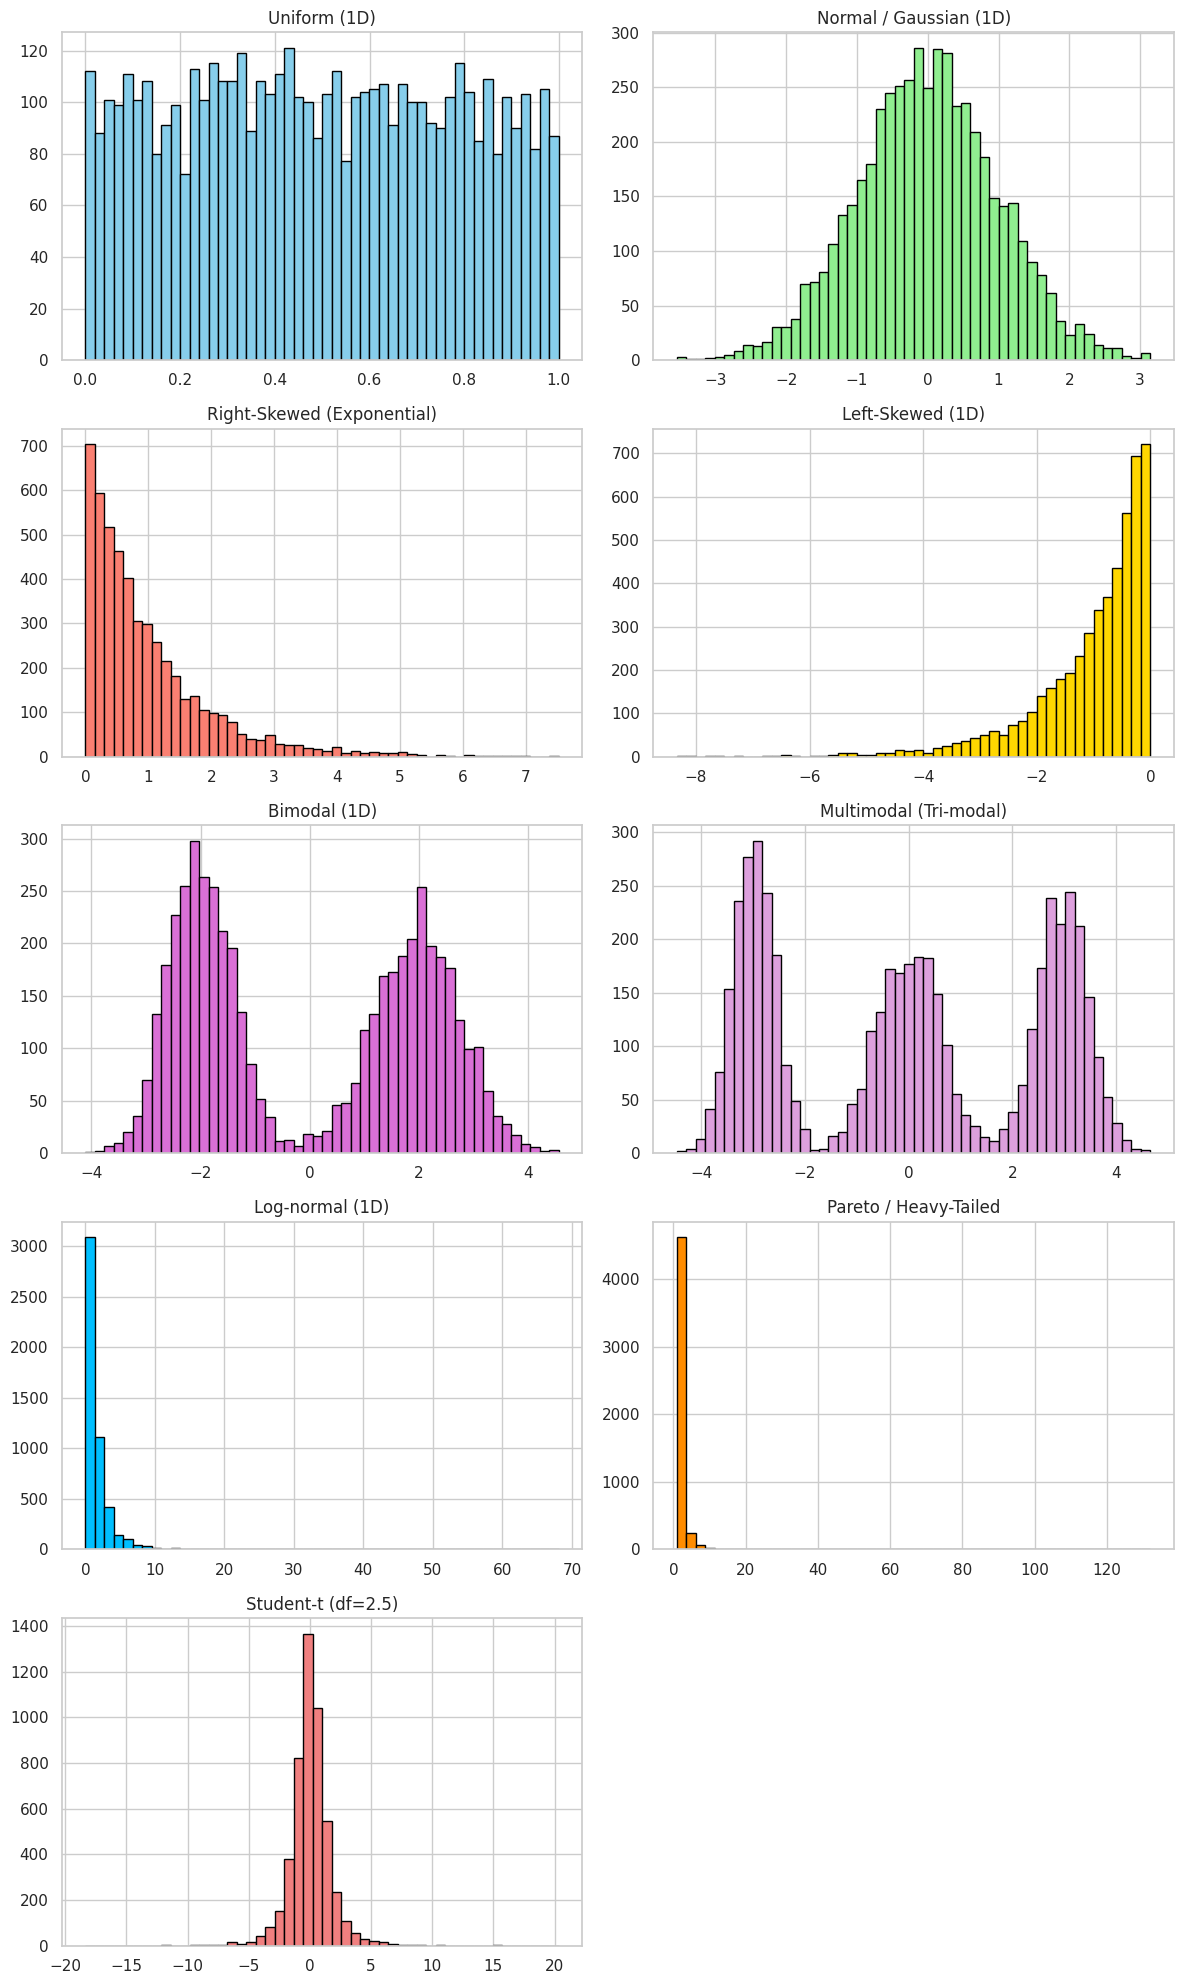

In [4]:
n = 5000
rng = np.random.default_rng()

# Create a 2-column subplot grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))
axes = axes.flatten()

# Helper function to plot in a specific subplot
def plot_hist(data, title, color, ax):
    ax.hist(data, bins=50, color=color, edgecolor='black')
    ax.set_title(title)
    ax.grid(True)

# 1. Uniform
uniform_1d = rng.uniform(0, 1, n)
save_series("uniform_1d", uniform_1d)
plot_hist(uniform_1d, "Uniform (1D)", color="skyblue", ax=axes[0])

# 2. Normal
normal_1d = rng.normal(0, 1, n)
save_series("normal_1d", normal_1d)
plot_hist(normal_1d, "Normal / Gaussian (1D)", color="lightgreen", ax=axes[1])

# 3. Right-skewed (Exponential)
right_skew_1d = rng.exponential(1.0, n)
save_series("right_skewed_1d", right_skew_1d)
plot_hist(right_skew_1d, "Right-Skewed (Exponential)", color="salmon", ax=axes[2])

# 4. Left-skewed
left_skew_1d = -rng.exponential(1.0, n)
save_series("left_skewed_1d", left_skew_1d)
plot_hist(left_skew_1d, "Left-Skewed (1D)", color="gold", ax=axes[3])

# 5. Bimodal
mix_mask = rng.random(n) < 0.5
bimodal_1d = np.empty(n)
bimodal_1d[mix_mask] = rng.normal(-2.0, 0.6, mix_mask.sum())
bimodal_1d[~mix_mask] = rng.normal(+2.0, 0.8, (~mix_mask).sum())
save_series("bimodal_1d", bimodal_1d)
plot_hist(bimodal_1d, "Bimodal (1D)", color="orchid", ax=axes[4])

# 6. Multimodal
r = rng.random(n)
multimodal_1d = np.empty(n)
multimodal_1d[r < 1/3] = rng.normal(-3, 0.4, (r < 1/3).sum())
mid_mask = (r >= 1/3) & (r < 2/3)
multimodal_1d[mid_mask] = rng.normal(0, 0.6, mid_mask.sum())
multimodal_1d[r >= 2/3] = rng.normal(3, 0.5, (r >= 2/3).sum())
save_series("multimodal_1d", multimodal_1d)
plot_hist(multimodal_1d, "Multimodal (Tri-modal)", color="plum", ax=axes[5])

# 7. Log-normal
lognormal_1d = rng.lognormal(0, 1, n)
save_series("lognormal_1d", lognormal_1d)
plot_hist(lognormal_1d, "Log-normal (1D)", color="deepskyblue", ax=axes[6])

# 8. Pareto
pareto_1d = rng.pareto(2.0, n) + 1
save_series("pareto_1d", pareto_1d)
plot_hist(pareto_1d, "Pareto / Heavy-Tailed", color="darkorange", ax=axes[7])

# 9. Student-t
t_1d = rng.standard_t(df=2.5, size=n)
save_series("student_t_1d", t_1d)
plot_hist(t_1d, "Student-t (df=2.5)", color="lightcoral", ax=axes[8])

# Hide the last subplot if unused
fig.delaxes(axes[9])

plt.tight_layout()
plt.show()

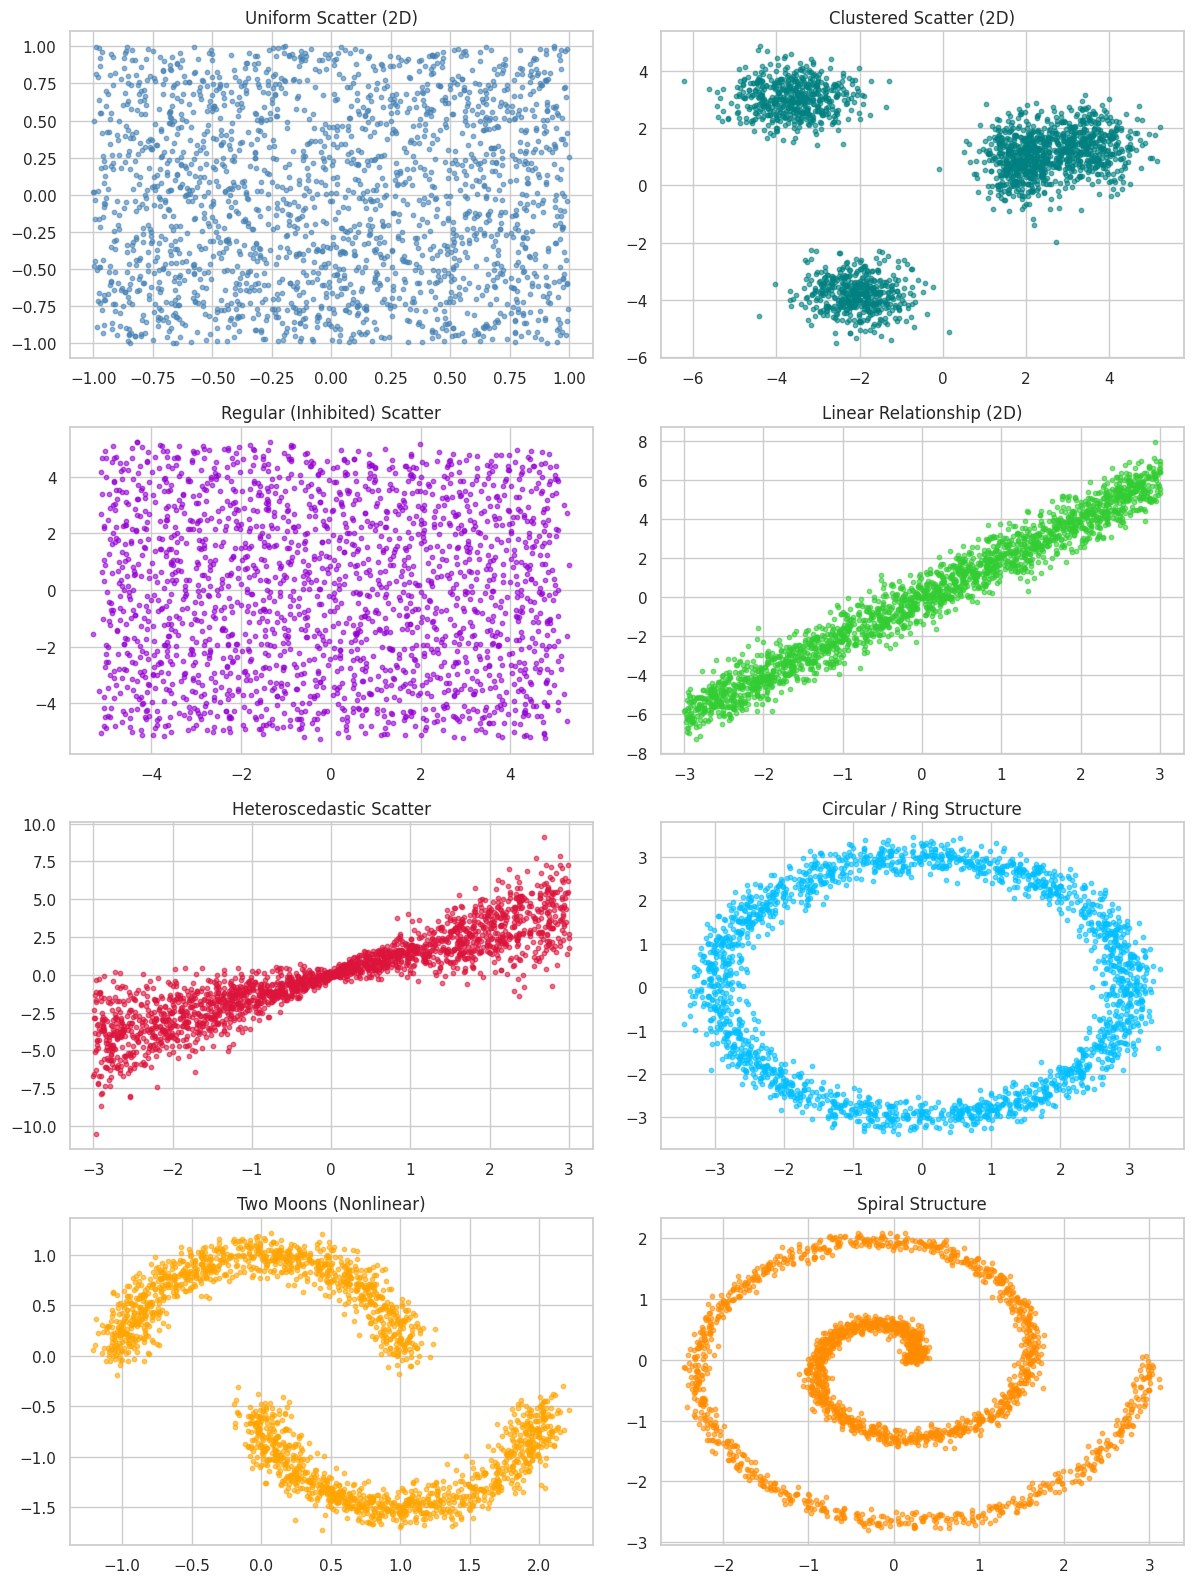

In [5]:
import matplotlib.pyplot as plt
import numpy as np

m = 2000
rng = np.random.default_rng()

# Create a 2-column subplot grid
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))
axes = axes.flatten()

# Helper function to plot in a specific subplot
def plot_scatter(x, y, title, color, ax):
    ax.scatter(x, y, s=10, color=color, alpha=0.6)
    ax.set_title(title)
    ax.grid(True)

# A. Uniform scatter
x_uni2d = rng.uniform(-1, 1, m)
y_uni2d = rng.uniform(-1, 1, m)
save_xy("uniform_scatter_2d", x_uni2d, y_uni2d)
plot_scatter(x_uni2d, y_uni2d, "Uniform Scatter (2D)", color="steelblue", ax=axes[0])

# B. Clustered (Gaussian blobs)
k = 4
centers = rng.uniform(-4, 4, size=(k, 2))
cluster_sizes = rng.multinomial(m, [1/k]*k)
xs, ys = [], []
for i in range(k):
    cov = np.array([[rng.uniform(0.1, 0.6), 0],
                    [0, rng.uniform(0.1, 0.6)]])
    pts = rng.multivariate_normal(mean=centers[i], cov=cov, size=cluster_sizes[i])
    xs.append(pts[:,0]); ys.append(pts[:,1])
x_clust, y_clust = np.concatenate(xs), np.concatenate(ys)
save_xy("clustered_scatter_2d", x_clust, y_clust)
plot_scatter(x_clust, y_clust, "Clustered Scatter (2D)", color="teal", ax=axes[1])

# C. Regular / inhibited (grid + jitter)
grid_n = int(np.ceil(np.sqrt(m)))
gx, gy = np.meshgrid(np.linspace(-5, 5, grid_n), np.linspace(-5, 5, grid_n))
gx, gy = gx.ravel()[:m], gy.ravel()[:m]
x_reg = gx + rng.normal(0, 0.15, len(gx))
y_reg = gy + rng.normal(0, 0.15, len(gy))
save_xy("regular_inhibited_scatter_2d", x_reg, y_reg)
plot_scatter(x_reg, y_reg, "Regular (Inhibited) Scatter", color="darkviolet", ax=axes[2])

# D. Linear relationship
x_lin = rng.uniform(-3, 3, m)
y_lin = 2.0 * x_lin + rng.normal(0, 0.7, m)
save_xy("linear_relation_2d", x_lin, y_lin)
plot_scatter(x_lin, y_lin, "Linear Relationship (2D)", color="limegreen", ax=axes[3])

# E. Heteroscedastic
x_hetero = rng.uniform(-3, 3, m)
noise = rng.normal(0, 0.2 + 0.6*np.abs(x_hetero), m)
y_hetero = 1.5 * x_hetero + noise
save_xy("heteroscedastic_2d", x_hetero, y_hetero)
plot_scatter(x_hetero, y_hetero, "Heteroscedastic Scatter", color="crimson", ax=axes[4])

# F. Circular / ring structure
r0 = 3.0
theta = rng.uniform(0, 2*np.pi, m)
radius = r0 + rng.normal(0, 0.2, m)
x_circ = radius * np.cos(theta)
y_circ = radius * np.sin(theta)
save_xy("circular_scatter_2d", x_circ, y_circ)
plot_scatter(x_circ, y_circ, "Circular / Ring Structure", color="deepskyblue", ax=axes[5])

# G. Two moons (nonlinear manifold)
n_half = m // 2
theta1 = rng.uniform(0, np.pi, n_half)
x1 = np.cos(theta1) + rng.normal(0, 0.1, n_half)
y1 = np.sin(theta1) + rng.normal(0, 0.1, n_half)
theta2 = rng.uniform(0, np.pi, m - n_half)
x2 = 1.0 - np.cos(theta2) + rng.normal(0, 0.1, m - n_half)
y2 = -np.sin(theta2) - 0.5 + rng.normal(0, 0.1, m - n_half)
x_moons = np.concatenate([x1, x2])
y_moons = np.concatenate([y1, y2])
save_xy("two_moons_2d", x_moons, y_moons)
plot_scatter(x_moons, y_moons, "Two Moons (Nonlinear)", color="orange", ax=axes[6])

# H. Spiral
t = np.linspace(0, 4*np.pi, m)
r = np.linspace(0.2, 3.0, m) + rng.normal(0, 0.05, m)
x_spiral = r * np.cos(t) + rng.normal(0, 0.05, m)
y_spiral = r * np.sin(t) + rng.normal(0, 0.05, m)
save_xy("spiral_2d", x_spiral, y_spiral)
plot_scatter(x_spiral, y_spiral, "Spiral Structure", color="darkorange", ax=axes[7])

plt.tight_layout()
plt.show()

In [6]:
# %% [summary] What got created
print("Saved CSV files in:", os.path.abspath(OUT_DIR))
print("\n1D datasets:")
print("- uniform_1d.csv")
print("- normal_1d.csv")
print("- right_skewed_1d.csv")
print("- left_skewed_1d.csv")
print("- bimodal_1d.csv")
print("- multimodal_1d.csv")
print("- lognormal_1d.csv")
print("- pareto_1d.csv")
print("- student_t_1d.csv")

print("\n2D datasets:")
print("- uniform_scatter_2d.csv")
print("- clustered_scatter_2d.csv")
print("- regular_inhibited_scatter_2d.csv")
print("- linear_relation_2d.csv")
print("- heteroscedastic_2d.csv")
print("- circular_scatter_2d.csv")
print("- two_moons_2d.csv")
print("- spiral_2d.csv")

Saved CSV files in: /kaggle/working/dummy_datasets

1D datasets:
- uniform_1d.csv
- normal_1d.csv
- right_skewed_1d.csv
- left_skewed_1d.csv
- bimodal_1d.csv
- multimodal_1d.csv
- lognormal_1d.csv
- pareto_1d.csv
- student_t_1d.csv

2D datasets:
- uniform_scatter_2d.csv
- clustered_scatter_2d.csv
- regular_inhibited_scatter_2d.csv
- linear_relation_2d.csv
- heteroscedastic_2d.csv
- circular_scatter_2d.csv
- two_moons_2d.csv
- spiral_2d.csv


### ***By Value Distribution / Scatter Type***

| Data type / pattern                  | Example dataset               | Typical model that works well                                                                       | Why it fits                                                                     |
| ------------------------------------ | ----------------------------- | --------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------- |
| **Linear**                           | `linear_relation_2d`          | **Linear Regression**, **Logistic Regression**, **Linear SVM**                                      | Relationships between features and targets are straight-line like (y = ax + b). |
| **Nonlinear but smooth**             | `spiral_2d`, `two_moons_2d`   | **Kernel SVM (RBF kernel)**, **Decision Trees**, **Random Forest**, **Neural Networks**             | They can learn curved or complex boundaries.                                    |
| **Highly clustered / piecewise**     | `clustered_scatter_2d`        | **k-NN**, **Decision Trees**, **Random Forest**, **Gaussian Mixture Models (GMM)**                  | These methods partition the space or learn local patterns.                      |
| **Circular / radial**                | `circular_scatter_2d`         | **RBF Kernel SVM**, **Neural Nets**, **GMM**                                                        | Radial kernels or probabilistic models fit circular structures well.            |
| **Uniform / sparse**                 | `uniform_scatter_2d`          | **Linear or regularized models**, **Naive Bayes**                                                   | Simple, low-variance models avoid overfitting when data is sparse.              |
| **Skewed / heavy-tailed**            | `pareto_1d`, `lognormal_1d`   | **Tree-based models (RandomForest, XGBoost, CatBoost)**, sometimes **log-transform + linear model** | Trees handle asymmetry, outliers, and non-Gaussian noise gracefully.            |
| **Multimodal (many peaks)**          | `bimodal_1d`, `multimodal_1d` | **Mixture Models (GMM)**, **Ensemble methods**, **Neural Networks**                                 | These can represent multiple “sub-distributions” in one dataset.                |
| **Noisy, heteroscedastic**           | `heteroscedastic_2d`          | **Gradient Boosting (XGBoost/LightGBM)**, **Gaussian Process Regression**                           | They adapt to changing variance and non-constant noise levels.                  |
| **Categorical / discrete-heavy**     | survey data, text, etc.       | **Tree-based models**, **Naive Bayes**, **TabPFN**, **CatBoost**                                    | Trees and TabPFN handle categorical features directly.                          |
| **High-dimensional (many features)** | gene expression, text         | **Regularized Linear Models (Lasso, Ridge)**, **SVM**, **TabPFN**, **AutoML (AutoGluon)**           | These prevent overfitting and handle sparse patterns.                           |


#### ***By Model Family Intuition***

| Model family                                          | Strengths                              | Weaknesses                               | Good for distributions            |
| ----------------------------------------------------- | -------------------------------------- | ---------------------------------------- | --------------------------------- |
| **Linear models (Logistic, Linear Reg.)**             | Simple, interpretable, fast            | Fail on nonlinear, multimodal data       | Linear, symmetric                 |
| **Tree-based (Decision Tree, RF, XGBoost, CatBoost)** | Nonlinear, robust, handle skew/missing | Less smooth boundaries                   | Skewed, heavy-tailed, mixed types |
| **SVM (Linear / RBF)**                                | Powerful with kernels, good margins    | Sensitive to scaling, slower on big data | Smooth nonlinear, circular        |
| **k-NN**                                              | Simple, local learner                  | High memory cost, sensitive to noise     | Clustered, well-separated         |
| **Neural Networks (MLP, CNN)**                        | Highly flexible, scalable              | Needs lots of data, tuning               | Complex nonlinear, multimodal     |
| **Probabilistic models (Naive Bayes, GMM, HMM)**      | Handle uncertainty, simple             | Assume independence / specific form      | Skewed, multimodal, small data    |
| **TabPFN / AutoGluon (AutoML)**                       | Learn many distributions automatically | Black-box, compute heavy                 | Works well across most types      |


### ***🧪 Full Jupyter Example: TabPFN vs SVM on “Two Moons” Dataset***

In [7]:
# %% [full comparison for two-moons dataset]

# --- Imports ---
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from tabpfn import TabPFNClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch

sns.set(style="whitegrid", context="notebook", palette="deep")

# --- Device setup ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Using device:", device)

✅ Using device: cuda


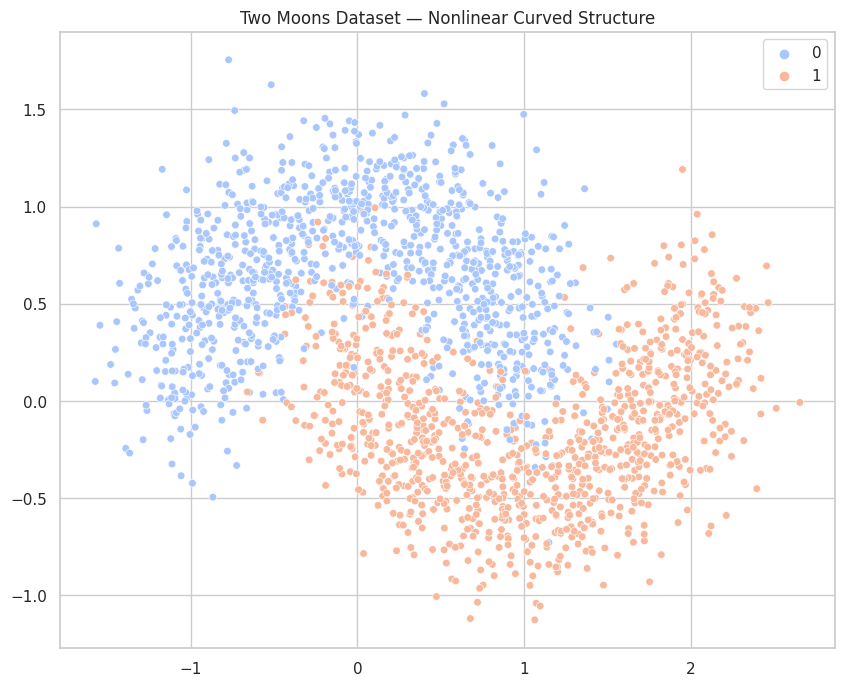

In [8]:
# --- Dataset: Two Moons ---
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X_moon, y_moon = make_moons(n_samples=2000, noise=0.25, random_state=42)
X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(
    X_moon, y_moon, test_size=0.3, stratify=y_moon, random_state=42
)

plt.figure(figsize=(10,8))
sns.scatterplot(x=X_moon[:,0], y=X_moon[:,1], hue=y_moon, palette="coolwarm", s=30)
plt.title("Two Moons Dataset — Nonlinear Curved Structure")
plt.show()

# --- Shared scaler ---
scaler_moon = StandardScaler().fit(X_moon_train)

#### ***⚙️ Train Models***

In [9]:
# --- 1️⃣ TabPFN (Meta-learned Transformer) ---
tabpfn_moon = TabPFNClassifier(device=device)
tabpfn_moon.fit(X_moon_train, y_moon_train)
tabpfn_moon_pred = tabpfn_moon.predict(X_moon_test)
tabpfn_moon_proba = tabpfn_moon.predict_proba(X_moon_test)[:,1]

# --- 2️⃣ SVM (RBF) — Suitable classical model ---
svm_moon = SVC(kernel="rbf", probability=True, gamma="scale", random_state=42)
svm_moon.fit(scaler_moon.transform(X_moon_train), y_moon_train)
svm_moon_pred = svm_moon.predict(scaler_moon.transform(X_moon_test))
svm_moon_proba = svm_moon.predict_proba(scaler_moon.transform(X_moon_test))[:,1]

# --- 3️⃣ Logistic Regression — Not suitable (linear boundary) ---
logreg_moon = LogisticRegression(max_iter=200, random_state=42)
logreg_moon.fit(scaler_moon.transform(X_moon_train), y_moon_train)
logreg_moon_pred = logreg_moon.predict(scaler_moon.transform(X_moon_test))
logreg_moon_proba = logreg_moon.predict_proba(scaler_moon.transform(X_moon_test))[:,1]

tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

In [10]:
# --- Evaluation helper ---
def eval_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }

In [11]:
# --- Compare all three ---
results_moon = pd.DataFrame([
    eval_model("TabPFN", y_moon_test, tabpfn_moon_pred, tabpfn_moon_proba),
    eval_model("SVM (RBF)", y_moon_test, svm_moon_pred, svm_moon_proba),
    eval_model("Logistic (Linear)", y_moon_test, logreg_moon_pred, logreg_moon_proba)
])

print("\n📊 Performance Comparison:")
display(results_moon.round(3))


📊 Performance Comparison:


,Model,Accuracy,F1,ROC_AUC
0,TabPFN,0.942,0.942,0.987
1,SVM (RBF),0.935,0.935,0.985
2,Logistic (Linear),0.878,0.878,0.951


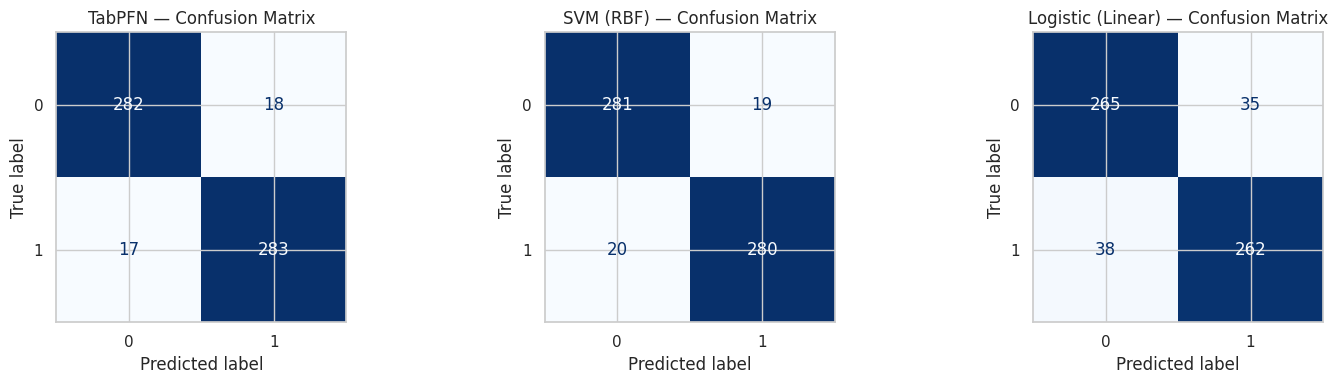

In [12]:
# %% [confusion matrices]
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, preds) in zip(
    axes,
    [
        ("TabPFN", tabpfn_moon_pred),
        ("SVM (RBF)", svm_moon_pred),
        ("Logistic (Linear)", logreg_moon_pred),
    ]
):
    cm = confusion_matrix(y_moon_test, preds)
    ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} — Confusion Matrix")
plt.tight_layout()
plt.show()

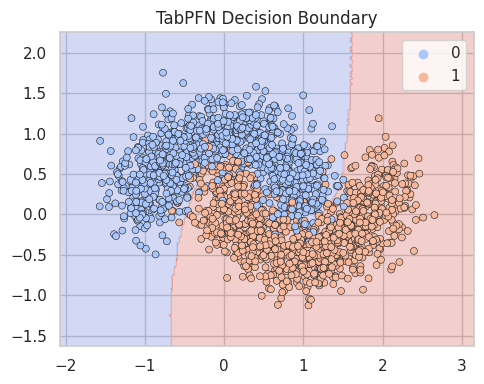

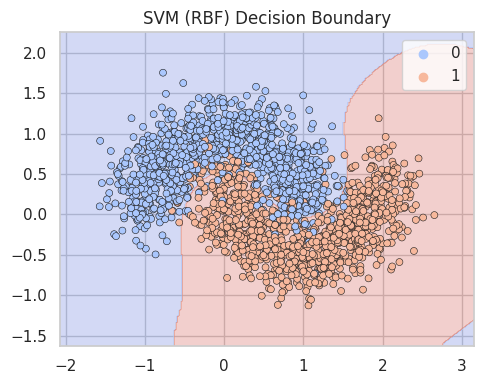

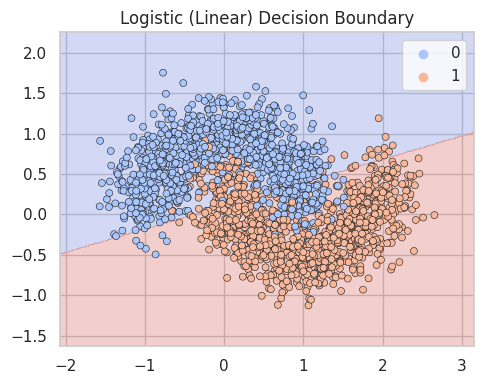

In [13]:
# %% [decision boundaries]
def plot_decision_boundary(model, X, y, title, scaler=None, grid=250, batch=20000):
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid),
                         np.linspace(y_min, y_max, grid))
    X_mesh = np.c_[xx.ravel(), yy.ravel()]
    if scaler is not None:
        X_mesh = scaler.transform(X_mesh)
    Z = np.empty(X_mesh.shape[0], dtype=int)
    for i in range(0, X_mesh.shape[0], batch):
        Z[i:i+batch] = model.predict(X_mesh[i:i+batch])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(5,4))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette="coolwarm", s=25, edgecolor="k")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_decision_boundary(tabpfn_moon, X_moon, y_moon, "TabPFN Decision Boundary")
plot_decision_boundary(svm_moon, X_moon, y_moon, "SVM (RBF) Decision Boundary", scaler=scaler_moon)
plot_decision_boundary(logreg_moon, X_moon, y_moon, "Logistic (Linear) Decision Boundary", scaler=scaler_moon)

## **Skewed / Heavy-Tailed — TabPFN vs CatBoost vs GaussianNB (misfit)**

In [14]:
# %% [full comparison for skewed/heavy-tailed dataset]

# --- Imports (safe to re-run) ---
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB   # <-- not suitable (assumes Gaussian)
from tabpfn import TabPFNClassifier
from catboost import CatBoostClassifier

sns.set(style="whitegrid", context="notebook", palette="deep")

# --- Device (Kaggle GPU safe) ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Using device:", device)

✅ Using device: cuda


In [15]:
# --- 1) Generate a skewed / heavy-tailed binary dataset (2D for easy visualization) ---
rng = np.random.default_rng(123)
n_skew = 4000
y_skew = rng.integers(0, 2, size=n_skew)

# Class 0: moderately heavy-tailed
x1_c0 = rng.lognormal(mean=0.0, sigma=1.0, size=(y_skew == 0).sum())
x2_c0 = rng.pareto(a=2.0, size=(y_skew == 0).sum()) + 1.0

# Class 1: heavier tails + shift
x1_c1 = rng.lognormal(mean=0.6, sigma=1.2, size=(y_skew == 1).sum())
x2_c1 = rng.pareto(a=1.5, size=(y_skew == 1).sum()) + 1.2

X1 = np.empty(n_skew); X2 = np.empty(n_skew)
X1[y_skew == 0] = x1_c0; X2[y_skew == 0] = x2_c0
X1[y_skew == 1] = x1_c1; X2[y_skew == 1] = x2_c1

# Optional: add a few extreme outliers to emphasize heavy tails
n_out = max(1, n_skew // 100)
out_idx = rng.choice(n_skew, size=n_out, replace=False)
X1[out_idx] *= rng.uniform(5, 15, size=n_out)
X2[out_idx] *= rng.uniform(5, 15, size=n_out)

X_skew = np.column_stack([X1, X2])

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


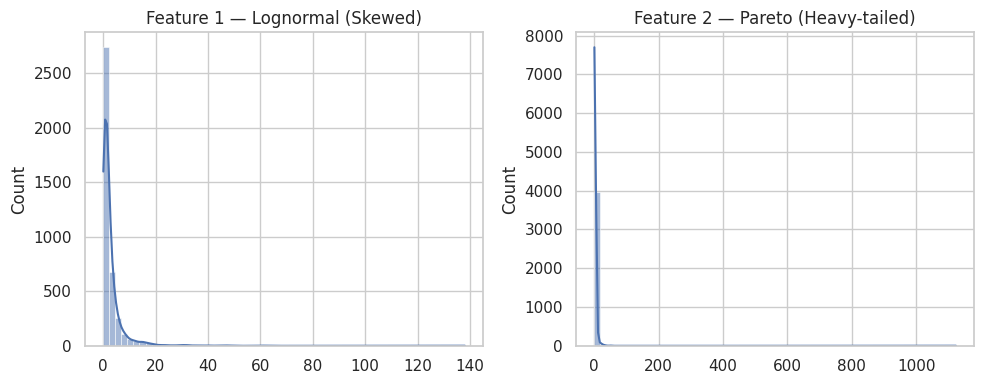

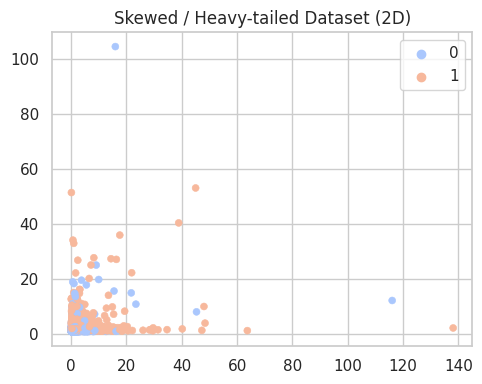

In [16]:
# Train/test split
X_skew_train, X_skew_test, y_skew_train, y_skew_test = train_test_split(
    X_skew, y_skew, test_size=0.3, stratify=y_skew, random_state=42
)

# --- Quick look at skewed marginals ---
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(X_skew[:,0], bins=60, ax=axes[0], kde=True)
axes[0].set_title("Feature 1 — Lognormal (Skewed)")
sns.histplot(X_skew[:,1], bins=60, ax=axes[1], kde=True)
axes[1].set_title("Feature 2 — Pareto (Heavy-tailed)")
plt.tight_layout(); plt.show()

# 2D scatter (downsample just for plotting clarity)
ds_mask = rng.choice(len(X_skew), size=min(2000, len(X_skew)), replace=False)
plt.figure(figsize=(5,4))
sns.scatterplot(x=X_skew[ds_mask,0], y=X_skew[ds_mask,1], hue=y_skew[ds_mask], palette="coolwarm", s=25, edgecolor=None)
plt.title("Skewed / Heavy-tailed Dataset (2D)")
plt.tight_layout(); plt.show()

In [17]:
# --- 2) Train models ---

# 2.1 TabPFN (handles many distributions out-of-the-box)
tabpfn_skew = TabPFNClassifier(device=device)
tabpfn_skew.fit(X_skew_train, y_skew_train)
tabpfn_skew_pred  = tabpfn_skew.predict(X_skew_test)
tabpfn_skew_proba = tabpfn_skew.predict_proba(X_skew_test)[:, 1]

# 2.2 CatBoost (robust to skew/outliers; no feature scaling needed)
cat_skew = CatBoostClassifier(
    loss_function="Logloss",
    iterations=300,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)
cat_skew.fit(X_skew_train, y_skew_train)
cat_skew_pred  = cat_skew.predict(X_skew_test).astype(int)
cat_skew_proba = cat_skew.predict_proba(X_skew_test)[:, 1]

# 2.3 Gaussian Naive Bayes — NOT suitable here (assumes Gaussian per feature)
gnb_skew = GaussianNB()
gnb_skew.fit(X_skew_train, y_skew_train)
gnb_skew_pred  = gnb_skew.predict(X_skew_test)
gnb_skew_proba = gnb_skew.predict_proba(X_skew_test)[:, 1]

In [18]:
# --- 3) Evaluate ---
def eval_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }

results_skew = pd.DataFrame([
    eval_model("TabPFN", y_skew_test, tabpfn_skew_pred, tabpfn_skew_proba),
    eval_model("CatBoost", y_skew_test, cat_skew_pred, cat_skew_proba),
    eval_model("GaussianNB (misfit)", y_skew_test, gnb_skew_pred, gnb_skew_proba),
])

print("\n📊 Performance Comparison — Skewed / Heavy-tailed:")
display(results_skew.round(3))


📊 Performance Comparison — Skewed / Heavy-tailed:


,Model,Accuracy,F1,ROC_AUC
0,TabPFN,0.675,0.713,0.749
1,CatBoost,0.643,0.666,0.722
2,GaussianNB (misfit),0.533,0.157,0.598


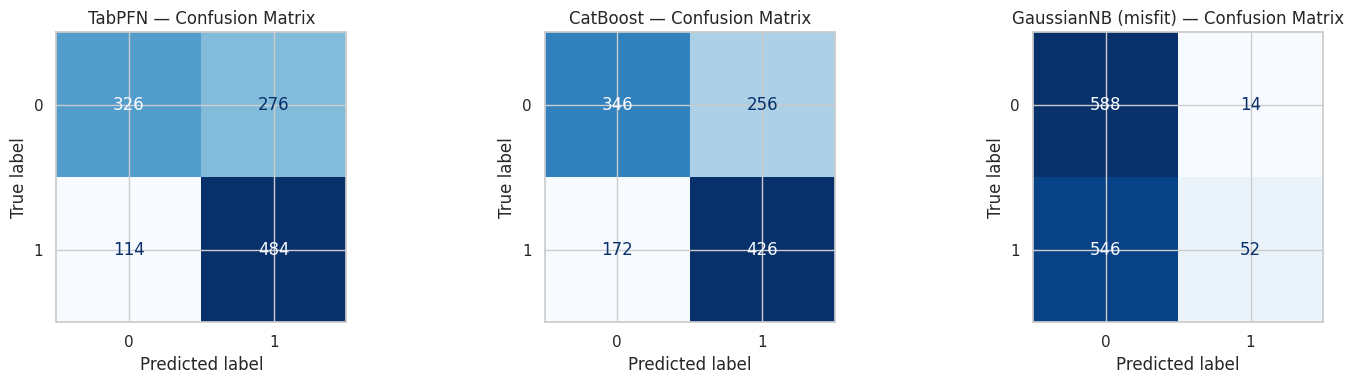

In [19]:
# --- 4) Confusion matrices ---
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, preds) in zip(
    axes,
    [
        ("TabPFN", tabpfn_skew_pred),
        ("CatBoost", cat_skew_pred),
        ("GaussianNB (misfit)", gnb_skew_pred),
    ]
):
    cm = confusion_matrix(y_skew_test, preds)
    ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} — Confusion Matrix")
plt.tight_layout(); plt.show()

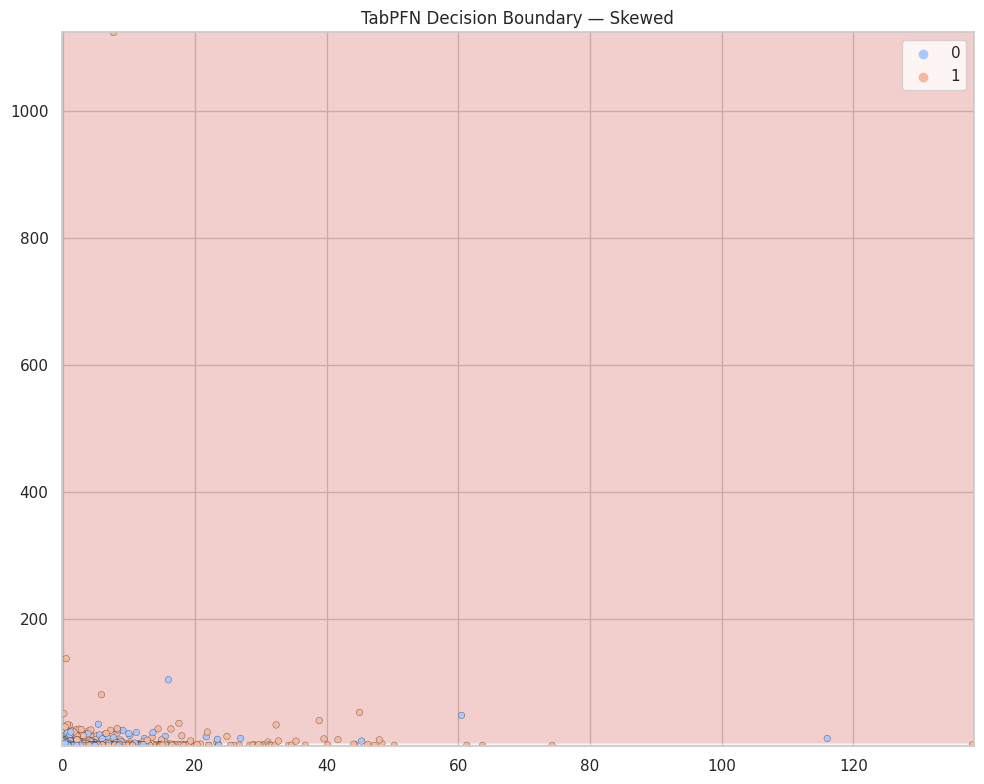

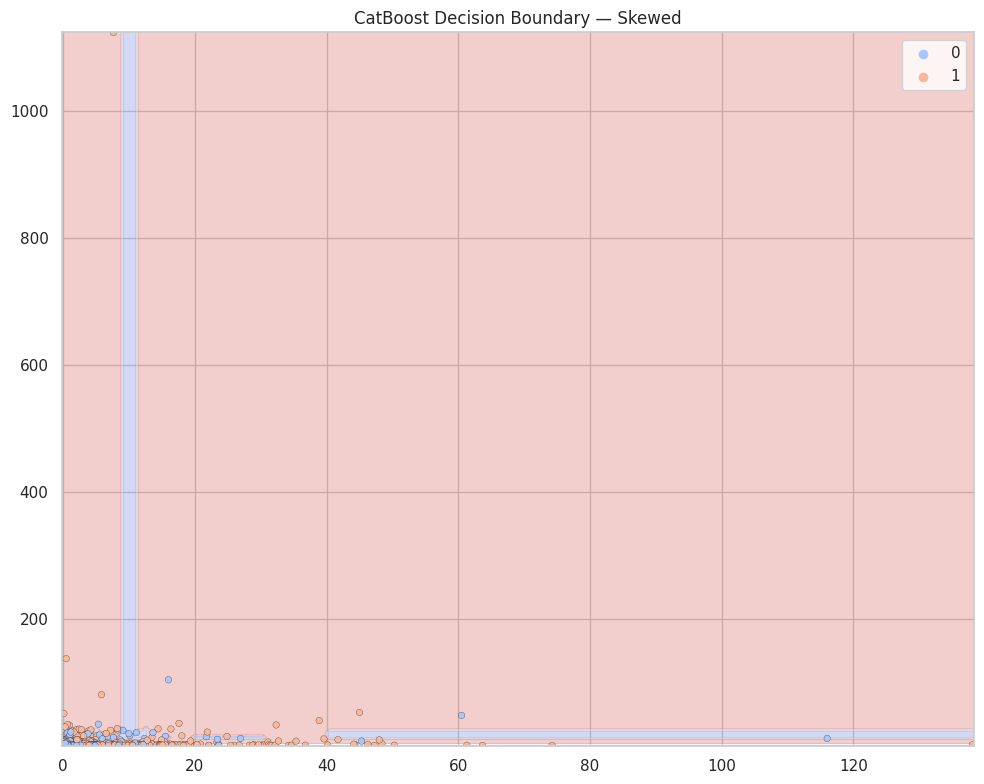

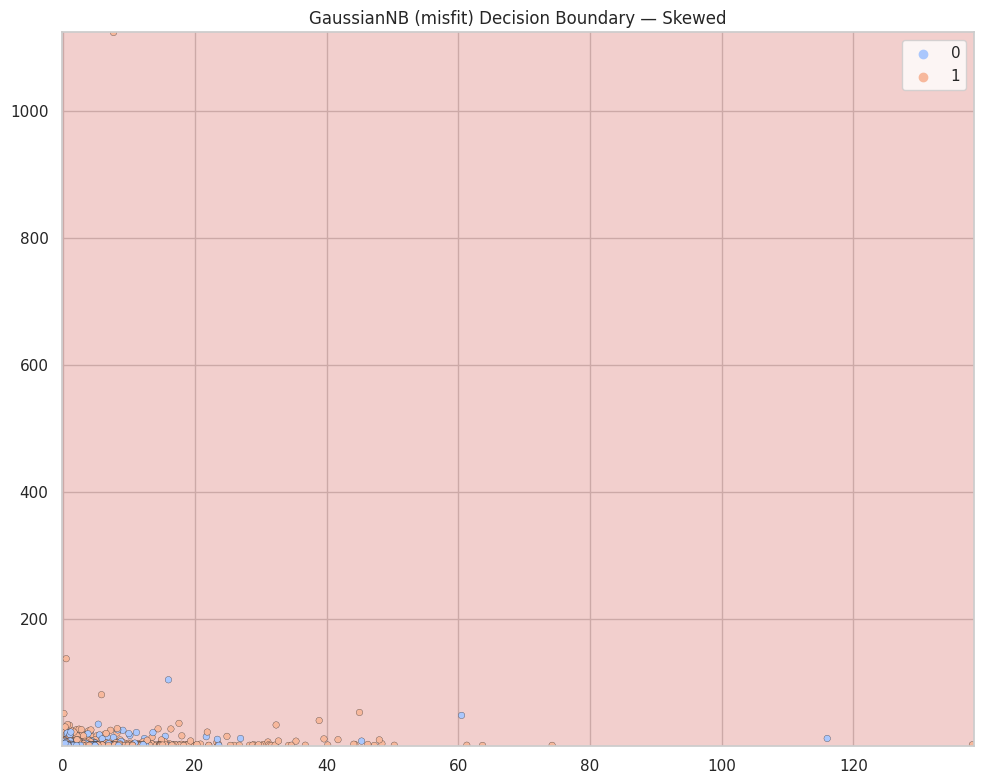

In [20]:
# --- 5) Decision boundaries (2D, batched & GPU-safe) ---
def plot_decision_boundary(model, X, y, title, grid=250, batch=20000, transform=None):
    x_min, x_max = X[:,0].min()-0.25, X[:,0].max()+0.25
    y_min, y_max = X[:,1].min()-0.25, X[:,1].max()+0.25
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid),
                         np.linspace(y_min, y_max, grid))
    X_mesh = np.c_[xx.ravel(), yy.ravel()]
    if transform is not None:
        X_mesh_t = transform(X_mesh)
    else:
        X_mesh_t = X_mesh

    Z = np.empty(X_mesh.shape[0], dtype=int)
    for i in range(0, X_mesh.shape[0], batch):
        Z[i:i+batch] = model.predict(X_mesh_t[i:i+batch])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10,8))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette="coolwarm", s=22, edgecolor="k", linewidth=0.2)
    plt.title(title)
    plt.tight_layout(); plt.show()

plot_decision_boundary(tabpfn_skew, X_skew, y_skew, "TabPFN Decision Boundary — Skewed")
plot_decision_boundary(cat_skew,    X_skew, y_skew, "CatBoost Decision Boundary — Skewed")
plot_decision_boundary(gnb_skew,    X_skew, y_skew, "GaussianNB (misfit) Decision Boundary — Skewed")

#### ***Plot in log space (clear view), predict in original space***
This squashes heavy tails so the dense region is visible while keeping predictions correct.

In [21]:
def plot_decision_boundary_logview(model, X, y, title,
                                   grid=300, batch=20000):
    # Forward/backward transforms
    def fwd(Z):  # to plotting space
        return np.log1p(np.clip(Z, a_min=0, a_max=None))
    def inv(Z):  # back to model/original space
        return np.expm1(Z)

    X_plot = fwd(X)

    # Limits in log space
    x_lo, x_hi = np.percentile(X_plot[:,0], [1, 99])
    y_lo, y_hi = np.percentile(X_plot[:,1], [1, 99])

    xx, yy = np.meshgrid(
        np.linspace(x_lo, x_hi, grid),
        np.linspace(y_lo, y_hi, grid)
    )
    # Mesh built in log space → invert to original before prediction
    X_mesh_plot = np.c_[xx.ravel(), yy.ravel()]
    X_mesh_orig = inv(X_mesh_plot)

    Z = np.empty(X_mesh_orig.shape[0], dtype=int)
    for i in range(0, X_mesh_orig.shape[0], batch):
        Z[i:i+batch] = model.predict(X_mesh_orig[i:i+batch])
    Z = Z.reshape(xx.shape)

    # Plot in log space
    plt.figure(figsize=(10,8))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X_plot[:,0], y=X_plot[:,1], hue=y, palette="coolwarm", s=18, edgecolor="k", linewidth=0.2)
    plt.title(f"{title}  (log1p view)")
    plt.xlabel("log1p(x1)"); plt.ylabel("log1p(x2)")
    plt.tight_layout(); plt.show()

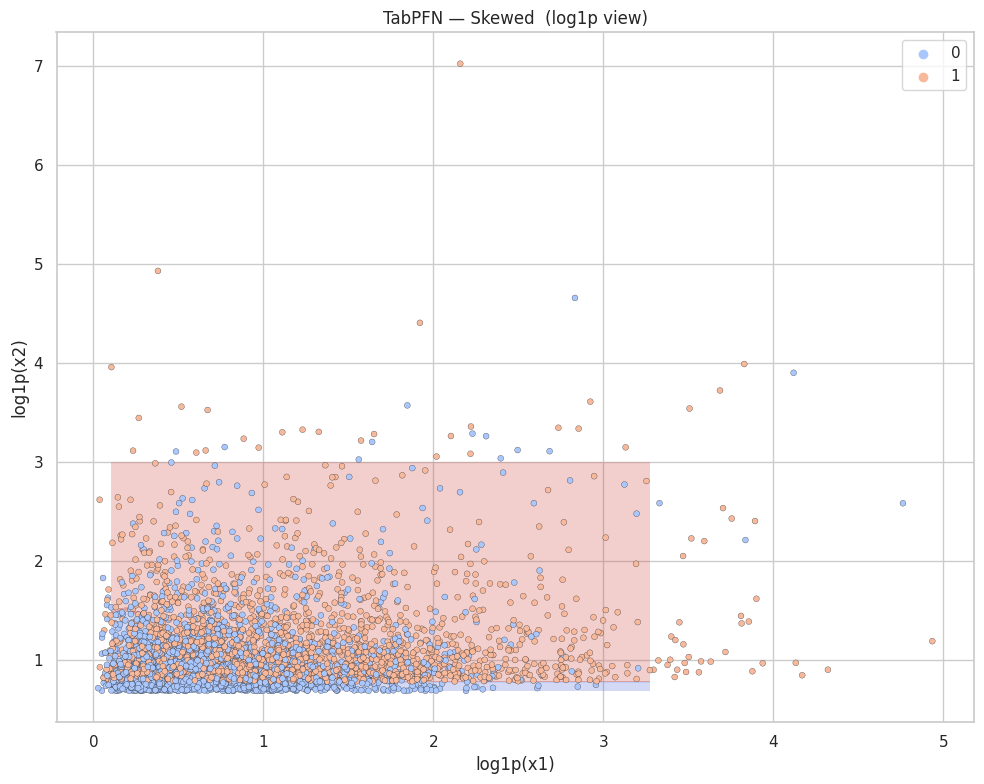

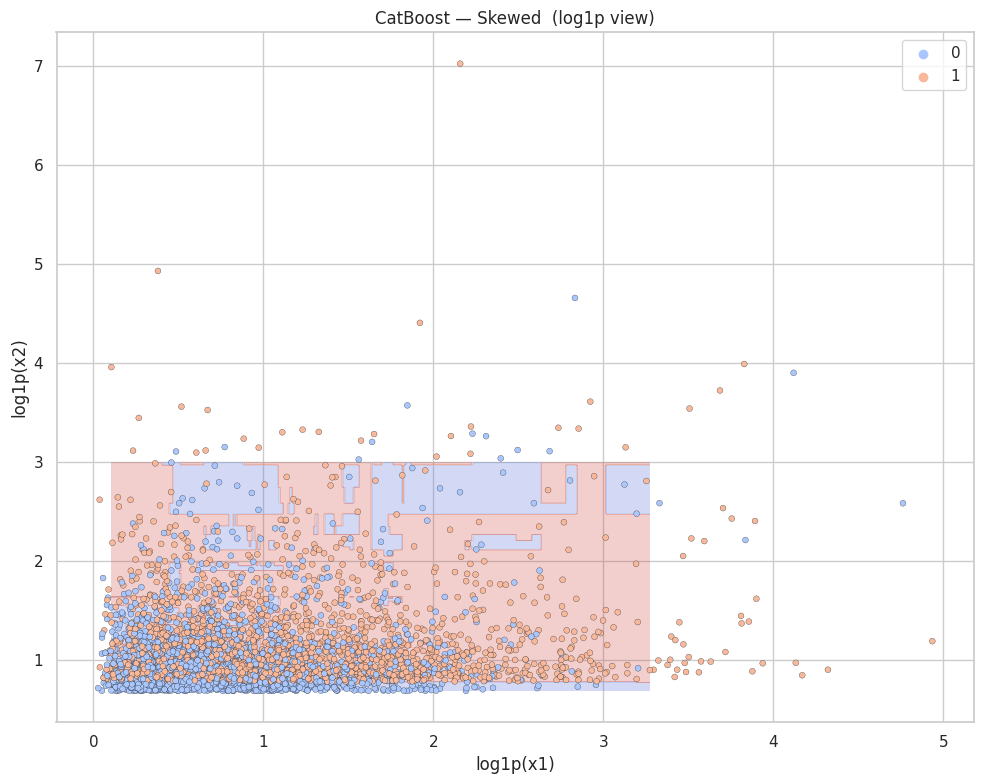

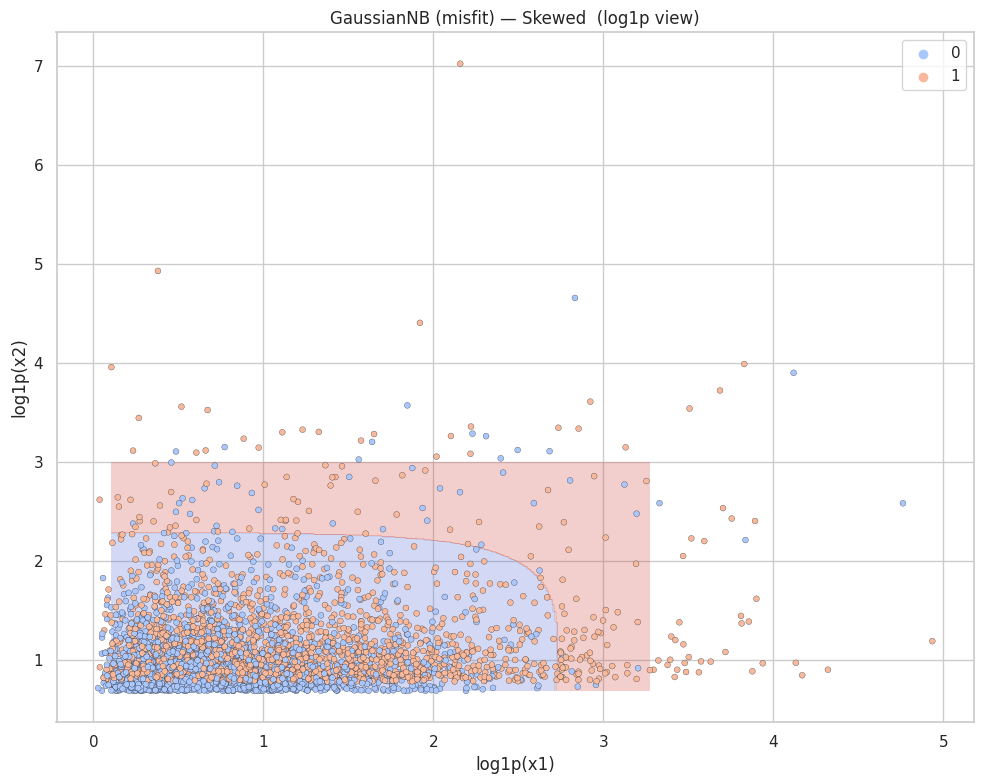

In [22]:
plot_decision_boundary_logview(tabpfn_skew, X_skew, y_skew, "TabPFN — Skewed")
plot_decision_boundary_logview(cat_skew,    X_skew, y_skew, "CatBoost — Skewed")
plot_decision_boundary_logview(gnb_skew,    X_skew, y_skew, "GaussianNB (misfit) — Skewed")

### ***Heteroscedastic Regression — CatBoost vs GB (quantile) vs Linear (misfit)***

In [23]:
# %% [setup] Imports & environment
import os, sys, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             confusion_matrix)  # (confusion unused; harmless)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Optional GPU awareness (for TabPFN)
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

sns.set(style="whitegrid", context="notebook", palette="deep")
print("✅ Device for TabPFN (if used):", DEVICE)

✅ Device for TabPFN (if used): cuda


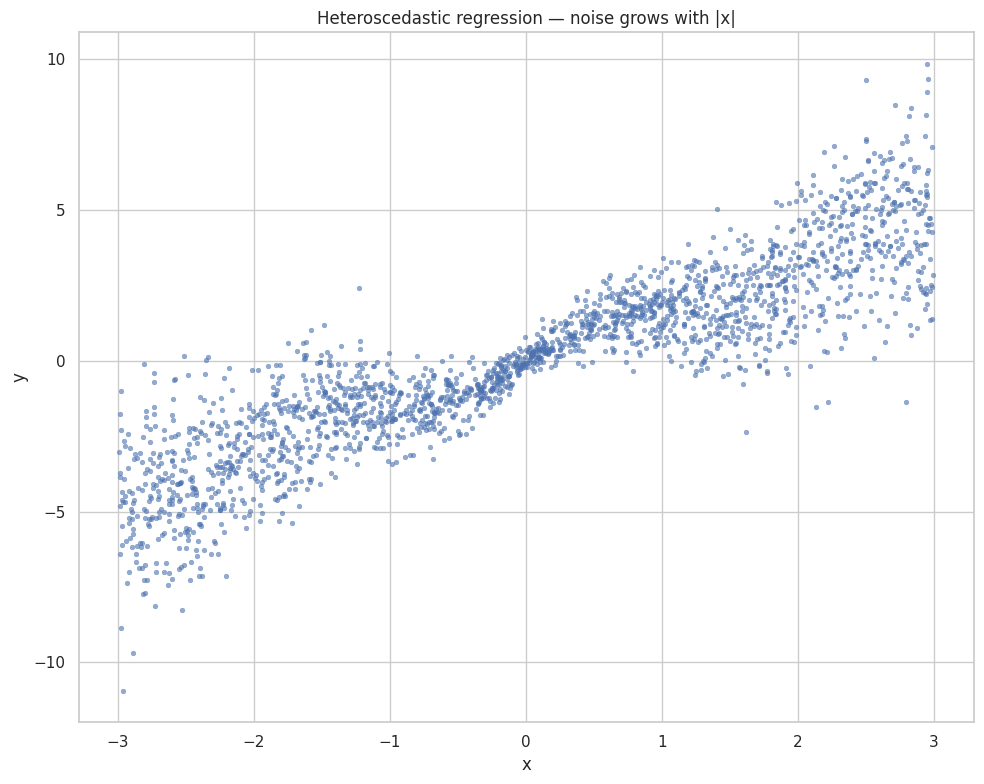

In [24]:
# %% [data] Heteroscedastic synthetic regression (noise ↑ with |x|)
rng = np.random.default_rng(7)
n_hetero = 3000

# 1D feature (easy to visualize)
X_hetero = rng.uniform(-3, 3, size=n_hetero)
# Smooth signal
f_true = 1.5 * X_hetero + 0.5 * np.sin(3 * X_hetero)
# Heteroscedastic noise: sigma depends on |x|
sigma = 0.25 + 0.6 * np.abs(X_hetero)
y_hetero = f_true + rng.normal(0, sigma)

# scikit-learn expects 2D X
X_hetero = X_hetero.reshape(-1, 1)

X_hetero_train, X_hetero_test, y_hetero_train, y_hetero_test = train_test_split(
    X_hetero, y_hetero, test_size=0.30, random_state=42
)

# Visual check (funnel shape)
plt.figure(figsize=(10,8))
sns.scatterplot(x=X_hetero_train.ravel(), y=y_hetero_train, s=12, alpha=0.6, edgecolor=None)
plt.title("Heteroscedastic regression — noise grows with |x|")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout(); plt.show()

In [25]:
# %% [models] CatBoost, GB-Quantiles, Linear (misfit), TabPFN (if available)
# --- 1) CatBoost (robust to heteroscedasticity/outliers) ---
from catboost import CatBoostRegressor
# cat_hetero = CatBoostRegressor(
#     loss_function="RMSE",
#     iterations=800,
#     depth=6,
#     learning_rate=0.05,
#     random_seed=42,
#     verbose=0
# )

cat_hetero = CatBoostRegressor()
cat_hetero.fit(X_hetero_train, y_hetero_train)

# --- 2) Gradient Boosting with quantile loss for uncertainty bands ---
gbr_med_hetero = GradientBoostingRegressor(
    loss="quantile", alpha=0.5, n_estimators=400, max_depth=3, random_state=42
)
gbr_lo_hetero  = GradientBoostingRegressor(
    loss="quantile", alpha=0.1, n_estimators=400, max_depth=3, random_state=42
)
gbr_hi_hetero  = GradientBoostingRegressor(
    loss="quantile", alpha=0.9, n_estimators=400, max_depth=3, random_state=42
)
gbr_med_hetero.fit(X_hetero_train, y_hetero_train)
gbr_lo_hetero.fit(X_hetero_train, y_hetero_train)
gbr_hi_hetero.fit(X_hetero_train, y_hetero_train)

# --- 3) Linear Regression (deliberate misfit under heteroscedasticity) ---
lin_hetero = LinearRegression()
lin_hetero.fit(X_hetero_train, y_hetero_train)

# --- 4) TabPFN Regressor (optional; guarded) ---
TABPFN_AVAILABLE = False
try:
    # If not installed on Kaggle image, you can pip install:
    # !pip -q install --upgrade tabpfn
    from tabpfn import TabPFNRegressor
    tabpfn_hetero = TabPFNRegressor(device=DEVICE)
    tabpfn_hetero.fit(X_hetero_train, y_hetero_train)
    TABPFN_AVAILABLE = True
    print("✅ TabPFNRegressor fitted.")
except Exception as e:
    print("⚠️ TabPFNRegressor not available. Skipping it.\n", repr(e))

Learning rate set to 0.046035
0:	learn: 2.9036967	total: 1.35ms	remaining: 1.35s
1:	learn: 2.7998091	total: 2.27ms	remaining: 1.13s
2:	learn: 2.7013215	total: 3.16ms	remaining: 1.05s
3:	learn: 2.6088112	total: 4.03ms	remaining: 1s
4:	learn: 2.5200240	total: 4.88ms	remaining: 971ms
5:	learn: 2.4370273	total: 5.78ms	remaining: 957ms
6:	learn: 2.3583972	total: 6.64ms	remaining: 942ms
7:	learn: 2.2851784	total: 7.45ms	remaining: 923ms
8:	learn: 2.2155236	total: 8.29ms	remaining: 912ms
9:	learn: 2.1488325	total: 9.38ms	remaining: 928ms
10:	learn: 2.0879244	total: 10.2ms	remaining: 922ms
11:	learn: 2.0291228	total: 11.1ms	remaining: 911ms
12:	learn: 1.9743743	total: 11.7ms	remaining: 889ms
13:	learn: 1.9227591	total: 12.7ms	remaining: 893ms
14:	learn: 1.8750091	total: 13.7ms	remaining: 896ms
15:	learn: 1.8295303	total: 14.5ms	remaining: 892ms
16:	learn: 1.7873603	total: 15.4ms	remaining: 891ms
17:	learn: 1.7477877	total: 16.2ms	remaining: 885ms
18:	learn: 1.7102299	total: 17.1ms	remaining: 8

tabpfn-v2-regressor.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

✅ TabPFNRegressor fitted.


In [26]:
# %% [eval] Metrics table
def reg_report(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
    }

cat_pred = cat_hetero.predict(X_hetero_test)
gbr_pred = gbr_med_hetero.predict(X_hetero_test)
lin_pred = lin_hetero.predict(X_hetero_test)

rows = [
    reg_report("CatBoost", y_hetero_test, cat_pred),
    reg_report("GB (Median)", y_hetero_test, gbr_pred),
    reg_report("Linear (misfit)", y_hetero_test, lin_pred),
]

if TABPFN_AVAILABLE:
    tabpfn_pred = tabpfn_hetero.predict(X_hetero_test)
    rows.append(reg_report("TabPFN (reg)", y_hetero_test, tabpfn_pred))

results_hetero = pd.DataFrame(rows)
print("📊 Performance — Heteroscedastic Regression")
display(results_hetero.round(4))

📊 Performance — Heteroscedastic Regression


,Model,R2,MAE,RMSE
0,CatBoost,0.7911,0.9696,1.3399
1,GB (Median),0.7987,0.9525,1.3156
2,Linear (misfit),0.7980,0.9849,1.3176
3,TabPFN (reg),0.8048,0.9395,1.2953


In [27]:
# %% [models] CatBoost, GB-Quantiles, Linear (misfit), TabPFN (if available)
# --- 1) CatBoost (robust to heteroscedasticity/outliers) ---
from catboost import CatBoostRegressor
# cat_hetero = CatBoostRegressor(
#     loss_function="RMSE",
#     iterations=800,
#     depth=6,
#     learning_rate=0.05,
#     random_seed=42,
#     verbose=0
# )

cat_hetero_02 = CatBoostRegressor(learning_rate=0.05)
cat_hetero_02.fit(X_hetero_train, y_hetero_train)

# --- 2) Gradient Boosting with quantile loss for uncertainty bands ---
gbr_med_hetero_02 = GradientBoostingRegressor(
    loss="quantile", alpha=0.5, n_estimators=400, max_depth=3, random_state=42
)
gbr_lo_hetero_02  = GradientBoostingRegressor(
    loss="quantile", alpha=0.1, n_estimators=400, max_depth=3, random_state=42
)
gbr_hi_hetero_02  = GradientBoostingRegressor(
    loss="quantile", alpha=0.9, n_estimators=400, max_depth=3, random_state=42
)
gbr_med_hetero_02.fit(X_hetero_train, y_hetero_train)
gbr_lo_hetero_02.fit(X_hetero_train, y_hetero_train)
gbr_hi_hetero_02.fit(X_hetero_train, y_hetero_train)

# --- 3) Linear Regression (deliberate misfit under heteroscedasticity) ---
lin_hetero_02 = LinearRegression()
lin_hetero_02.fit(X_hetero_train, y_hetero_train)

# # --- 4) TabPFN Regressor (optional; guarded) ---
# TABPFN_AVAILABLE = False
# try:
#     # If not installed on Kaggle image, you can pip install:
#     # !pip -q install --upgrade tabpfn
#     from tabpfn import TabPFNRegressor
#     tabpfn_hetero_02 = TabPFNRegressor(device=DEVICE)
#     tabpfn_hetero_02.fit(X_hetero_train, y_hetero_train)
#     TABPFN_AVAILABLE = True
#     print("✅ TabPFNRegressor fitted.")
# except Exception as e:
#     print("⚠️ TabPFNRegressor not available. Skipping it.\n", repr(e))

from tabpfn import TabPFNRegressor
tabpfn_hetero_02 = TabPFNRegressor(device=DEVICE)
tabpfn_hetero_02.fit(X_hetero_train, y_hetero_train)


from tabpfn_extensions import AutoTabPFNRegressor
autotabpfn_hetero = AutoTabPFNRegressor(device=device)
autotabpfn_hetero.fit(X_hetero_train, y_hetero_train)

0:	learn: 2.8943443	total: 1.2ms	remaining: 1.2s
1:	learn: 2.7820926	total: 2.1ms	remaining: 1.05s
2:	learn: 2.6762204	total: 2.92ms	remaining: 970ms
3:	learn: 2.5772484	total: 3.69ms	remaining: 920ms
4:	learn: 2.4827279	total: 4.74ms	remaining: 943ms
5:	learn: 2.3948662	total: 5.57ms	remaining: 923ms
6:	learn: 2.3113391	total: 6.38ms	remaining: 906ms
7:	learn: 2.2337962	total: 7.34ms	remaining: 911ms
8:	learn: 2.1614159	total: 8.18ms	remaining: 900ms
9:	learn: 2.0925649	total: 9.04ms	remaining: 895ms
10:	learn: 2.0299466	total: 9.93ms	remaining: 893ms
11:	learn: 1.9700090	total: 10.8ms	remaining: 887ms
12:	learn: 1.9143586	total: 11.4ms	remaining: 864ms
13:	learn: 1.8622271	total: 12.2ms	remaining: 859ms
14:	learn: 1.8139342	total: 13ms	remaining: 853ms
15:	learn: 1.7687023	total: 13.8ms	remaining: 850ms
16:	learn: 1.7272575	total: 14.8ms	remaining: 855ms
17:	learn: 1.6885853	total: 15.6ms	remaining: 851ms
18:	learn: 1.6521736	total: 16.4ms	remaining: 847ms
19:	learn: 1.6193874	total:

tabpfn-v2-regressor.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

tabpfn-v2-regressor-2noar4o2.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

tabpfn-v2-regressor-09gpqh39.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

tabpfn-v2-regressor-wyl4o83o.ckpt:   0%|          | 0.00/23.2M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

AutoTabPFNRegressor(device='cuda')

In [28]:
# %% [eval] Metrics table
def reg_report(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
    }

cat_pred_02 = cat_hetero_02.predict(X_hetero_test)
gbr_pred_02 = gbr_med_hetero_02.predict(X_hetero_test)
lin_pred_02= lin_hetero_02.predict(X_hetero_test)

rows = [
    reg_report("CatBoost", y_hetero_test, cat_pred_02),
    reg_report("GB (Median)", y_hetero_test, gbr_pred_02),
    reg_report("Linear (misfit)", y_hetero_test, lin_pred_02),
]

tabpfn_pred_02 = tabpfn_hetero_02.predict(X_hetero_test)
rows.append(reg_report("TabPFN (reg)", y_hetero_test, tabpfn_pred_02))

autotabpfn_pred = autotabpfn_hetero.predict(X_hetero_test)
rows.append(reg_report("AUTO-TabPFN (reg)", y_hetero_test, autotabpfn_pred))

results_hetero = pd.DataFrame(rows)
print("📊 Performance — Heteroscedastic Regression")
display(results_hetero.round(4))

📊 Performance — Heteroscedastic Regression


,Model,R2,MAE,RMSE
0,CatBoost,0.7904,0.9715,1.3423
1,GB (Median),0.7987,0.9525,1.3156
2,Linear (misfit),0.7980,0.9849,1.3176
3,TabPFN (reg),0.8048,0.9395,1.2953
4,AUTO-TabPFN (reg),0.8049,0.9396,1.2951


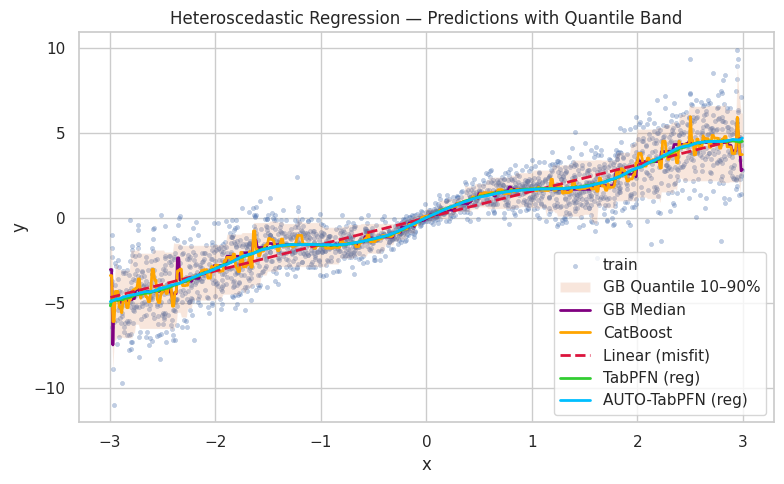

In [30]:
# %% [viz] Prediction curves + quantile band (shows heteroscedasticity) — UPDATED
xg = np.linspace(X_hetero.min(), X_hetero.max(), 500).reshape(-1, 1)

# Quantile bands (from GB models)
gbr_med = gbr_med_hetero_02.predict(xg)
gbr_lo  = gbr_lo_hetero_02.predict(xg)
gbr_hi  = gbr_hi_hetero_02.predict(xg)

# Other curves
cat_curve      = cat_hetero_02.predict(xg)
lin_curve      = lin_hetero_02.predict(xg)
tabpfn_curve   = tabpfn_hetero_02.predict(xg)   if 'tabpfn_hetero_02'   in globals() else None
autotab_curve  = autotabpfn_hetero.predict(xg)  if 'autotabpfn_hetero'  in globals() else None

plt.figure(figsize=(8,5))
sns.scatterplot(x=X_hetero_train.ravel(), y=y_hetero_train, s=10, alpha=0.35, edgecolor=None, label="train")

plt.fill_between(xg.ravel(), gbr_lo, gbr_hi, alpha=0.20, label="GB Quantile 10–90%")
plt.plot(xg, gbr_med,     label="GB Median", linewidth=2, color="purple")
plt.plot(xg, cat_curve,   label="CatBoost", linewidth=2, color="orange")
plt.plot(xg, lin_curve,   label="Linear (misfit)", linewidth=2, linestyle="--", color="crimson")

if tabpfn_curve is not None:
    plt.plot(xg, tabpfn_curve,  label="TabPFN (reg)", linewidth=2, color="limegreen")
if autotab_curve is not None:
    plt.plot(xg, autotab_curve, label="AUTO-TabPFN (reg)", linewidth=2, color="deepskyblue")

plt.title("Heteroscedastic Regression — Predictions with Quantile Band")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.tight_layout(); plt.show()

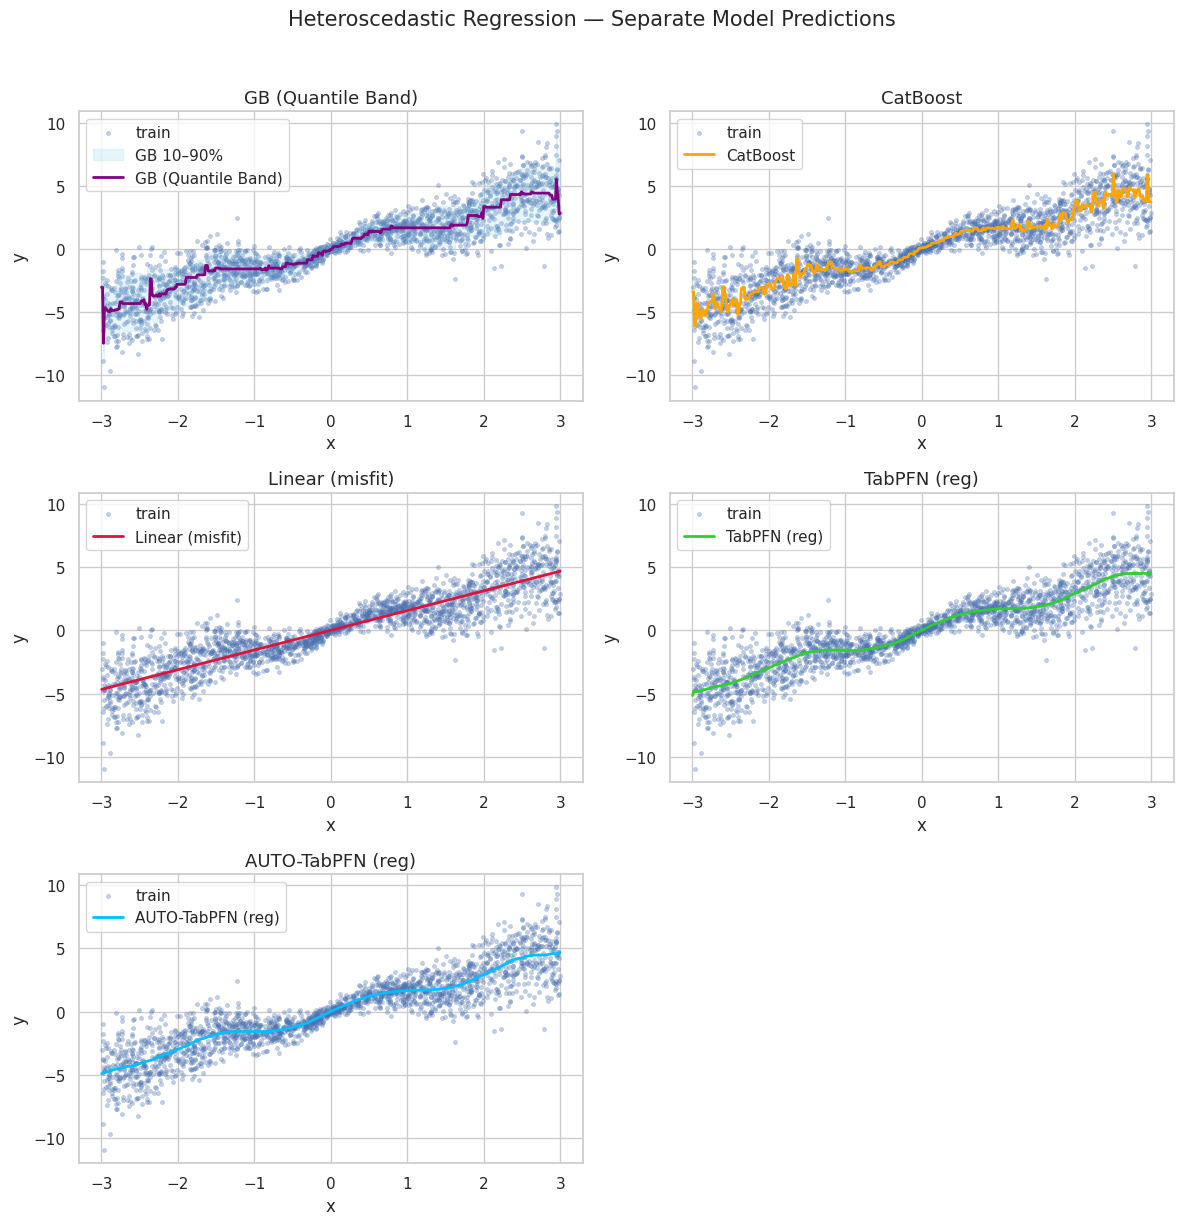

In [34]:
# %% [viz] Separate 2-column plots for each model — UPDATED

xg = np.linspace(X_hetero.min(), X_hetero.max(), 500).reshape(-1, 1)

# Precompute curves
curves = {
    "GB (Quantile Band)": {
        "curve": gbr_med_hetero_02.predict(xg),
        "lo":    gbr_lo_hetero_02.predict(xg),
        "hi":    gbr_hi_hetero_02.predict(xg),
        "color": "purple"
    },
    "CatBoost": {
        "curve": cat_hetero_02.predict(xg),
        "lo": None, "hi": None, "color": "orange"
    },
    "Linear (misfit)": {
        "curve": lin_hetero_02.predict(xg),
        "lo": None, "hi": None, "color": "crimson"
    },
}

if 'tabpfn_hetero_02' in globals():
    curves["TabPFN (reg)"] = {
        "curve": tabpfn_hetero_02.predict(xg),
        "lo": None, "hi": None, "color": "limegreen"
    }
if 'autotabpfn_hetero' in globals():
    curves["AUTO-TabPFN (reg)"] = {
        "curve": autotabpfn_hetero.predict(xg),
        "lo": None, "hi": None, "color": "deepskyblue"
    }

# Make a 2-column grid
names = list(curves.keys())
n_models = len(names)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4*nrows))
axes = np.array(axes).reshape(-1)  # flatten even if single row

for ax, name in zip(axes, names):
    cfg = curves[name]
    sns.scatterplot(
        x=X_hetero_train.ravel(), y=y_hetero_train,
        s=10, alpha=0.35, edgecolor=None, label="train", ax=ax
    )
    if cfg["lo"] is not None and cfg["hi"] is not None:
        ax.fill_between(xg.ravel(), cfg["lo"], cfg["hi"], alpha=0.20, label="GB 10–90%", color="skyblue")
    ax.plot(xg, cfg["curve"], color=cfg["color"], linewidth=2, label=name)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend()

# Hide any unused cells
for j in range(len(names), len(axes)):
    axes[j].axis("off")

plt.suptitle("Heteroscedastic Regression — Separate Model Predictions", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

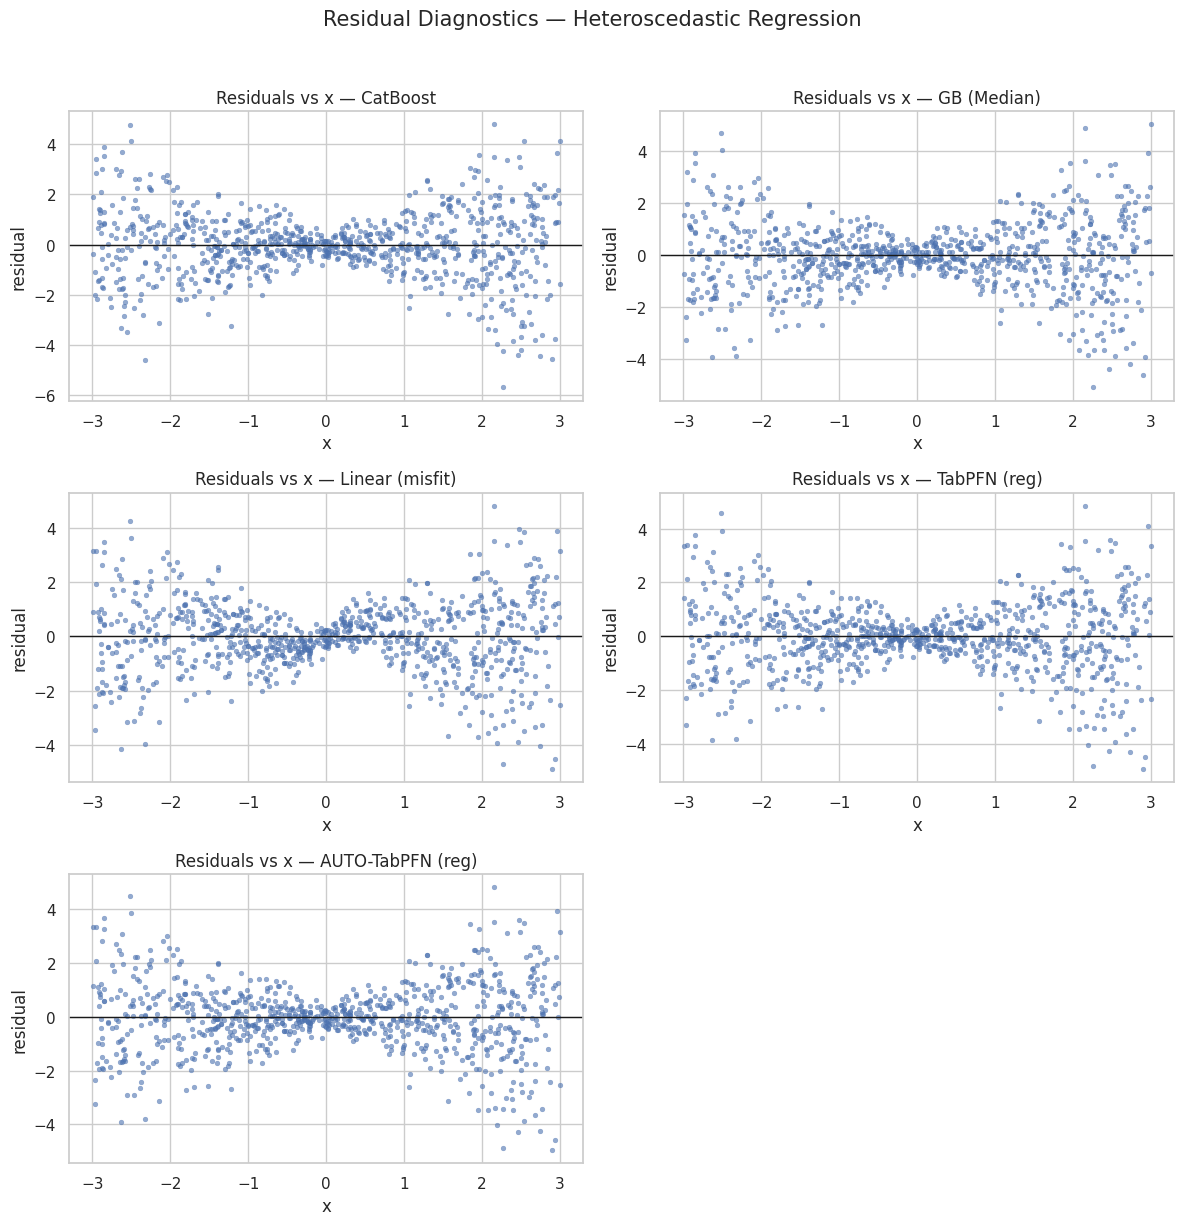

In [35]:
# %% [diagnostics] Residuals vs x — 2-column grid view — UPDATED

def compute_residuals(x, y_true, model):
    y_hat = model.predict(x)
    return x.ravel(), y_true - y_hat

# Assemble models
model_res_list = [
    ("CatBoost",        cat_hetero_02),
    ("GB (Median)",     gbr_med_hetero_02),
    ("Linear (misfit)", lin_hetero_02),
]
if 'tabpfn_hetero_02' in globals():
    model_res_list.append(("TabPFN (reg)", tabpfn_hetero_02))
if 'autotabpfn_hetero' in globals():
    model_res_list.append(("AUTO-TabPFN (reg)", autotabpfn_hetero))

n_models = len(model_res_list)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, (name, model) in zip(axes, model_res_list):
    xvals, residuals = compute_residuals(X_hetero_test, y_hetero_test, model)
    sns.scatterplot(x=xvals, y=residuals, s=12, alpha=0.6, edgecolor=None, ax=ax)
    ax.axhline(0, lw=1, color="k")
    ax.set_title(f"Residuals vs x — {name}")
    ax.set_xlabel("x"); ax.set_ylabel("residual")

for j in range(len(model_res_list), len(axes)):
    axes[j].axis("off")

plt.suptitle("Residual Diagnostics — Heteroscedastic Regression", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [36]:
# %% [export] (optional) Save results
out_dir = "hetero_outputs"
os.makedirs(out_dir, exist_ok=True)
results_hetero.round(6).to_csv(os.path.join(out_dir, "hetero_results.csv"), index=False)
np.save(os.path.join(out_dir, "X_hetero_train.npy"), X_hetero_train)
np.save(os.path.join(out_dir, "y_hetero_train.npy"), y_hetero_train)
np.save(os.path.join(out_dir, "X_hetero_test.npy"),  X_hetero_test)
np.save(os.path.join(out_dir, "y_hetero_test.npy"),  y_hetero_test)
print(f"✔️ Saved metrics CSV and splits in: {out_dir}")

✔️ Saved metrics CSV and splits in: hetero_outputs


## ***Hyperparameter Tuning Section (Cleanly Namespaced with _tuned)***

In [37]:
# %% [tune-setup] CV + scoring configuration
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform

# Cross-validation and scoring config
cv_hetero_tuned = KFold(n_splits=5, shuffle=True, random_state=42)
SCORING_TUNED = "neg_mean_absolute_error"  # MAE is more robust for heteroscedastic data
N_ITER_TUNED = 25  # adjust to 50–100 for longer search
N_JOBS_TUNED = -1
RANDOM_STATE_TUNED = 42

In [38]:
# %% [tune-catboost]
from catboost import CatBoostRegressor

cat_base_tuned = CatBoostRegressor(
    loss_function="RMSE",
    verbose=0,
    random_seed=RANDOM_STATE_TUNED
)

cat_param_dist_tuned = {
    "iterations": randint(300, 1201),
    "depth": randint(4, 11),
    "learning_rate": uniform(0.01, 0.25),
    "l2_leaf_reg": uniform(1.0, 9.0),
    "bagging_temperature": uniform(0.0, 1.0),
    "leaf_estimation_iterations": randint(1, 25),
}

cat_tuner = RandomizedSearchCV(
    estimator=cat_base_tuned,
    param_distributions=cat_param_dist_tuned,
    n_iter=N_ITER_TUNED,
    scoring=SCORING_TUNED,
    cv=cv_hetero_tuned,
    n_jobs=N_JOBS_TUNED,
    random_state=RANDOM_STATE_TUNED,
    refit=True,
    verbose=1
)

cat_tuner.fit(X_hetero_train, y_hetero_train)
print("✅ Best CatBoost hyperparameters:")
print(cat_tuner.best_params_)

cat_hetero_tuned = cat_tuner.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
✅ Best CatBoost hyperparameters:
{'bagging_temperature': 0.9922115592912175, 'depth': 4, 'iterations': 759, 'l2_leaf_reg': 6.504878444394528, 'leaf_estimation_iterations': 12, 'learning_rate': 0.01576560626035394}


In [39]:
# %% [tune-gbr]
from sklearn.ensemble import GradientBoostingRegressor

gbr_base_tuned = GradientBoostingRegressor(loss="quantile", alpha=0.5, random_state=RANDOM_STATE_TUNED)

gbr_param_dist_tuned = {
    "n_estimators": randint(200, 1201),
    "learning_rate": uniform(0.01, 0.3),
    "max_depth": randint(2, 7),
    "subsample": uniform(0.6, 0.4),
    "min_samples_leaf": randint(1, 21),
    "min_samples_split": randint(2, 21)
}

gbr_tuner = RandomizedSearchCV(
    estimator=gbr_base_tuned,
    param_distributions=gbr_param_dist_tuned,
    n_iter=N_ITER_TUNED,
    scoring=SCORING_TUNED,
    cv=cv_hetero_tuned,
    n_jobs=N_JOBS_TUNED,
    random_state=RANDOM_STATE_TUNED,
    refit=True,
    verbose=1
)

gbr_tuner.fit(X_hetero_train, y_hetero_train)
print("✅ Best GradientBoosting (Median) hyperparameters:")
print(gbr_tuner.best_params_)

# Save tuned median regressor
gbr_med_hetero_tuned = gbr_tuner.best_estimator_

# Reuse best parameters for quantile models
best_gbr_params = gbr_tuner.best_params_.copy()
best_lo, best_hi = best_gbr_params.copy(), best_gbr_params.copy()
best_lo["alpha"] = 0.1
best_hi["alpha"] = 0.9

gbr_lo_hetero_tuned = GradientBoostingRegressor(**best_lo, random_state=RANDOM_STATE_TUNED).fit(X_hetero_train, y_hetero_train)
gbr_hi_hetero_tuned = GradientBoostingRegressor(**best_hi, random_state=RANDOM_STATE_TUNED).fit(X_hetero_train, y_hetero_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
✅ Best GradientBoosting (Median) hyperparameters:
{'learning_rate': 0.03221339552022711, 'max_depth': 3, 'min_samples_leaf': 9, 'min_samples_split': 8, 'n_estimators': 400, 'subsample': 0.8493192507310232}


In [40]:
# %% [fit-linear-tuned]
from sklearn.linear_model import LinearRegression
lin_hetero_tuned = LinearRegression().fit(X_hetero_train, y_hetero_train)

In [41]:
# %% [eval-tuned]
def reg_report(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
    }

# Predictions
cat_pred_tuned = cat_hetero_tuned.predict(X_hetero_test)
gbr_pred_tuned = gbr_med_hetero_tuned.predict(X_hetero_test)
lin_pred_tuned = lin_hetero_tuned.predict(X_hetero_test)

rows_tuned = [
    reg_report("CatBoost (tuned)", y_hetero_test, cat_pred_tuned),
    reg_report("GB (Median tuned)", y_hetero_test, gbr_pred_tuned),
    reg_report("Linear (misfit)", y_hetero_test, lin_pred_tuned),
]

# Add TabPFN & AutoTabPFN if available
if "tabpfn_hetero_02" in globals():
    tabpfn_pred_tuned = tabpfn_hetero_02.predict(X_hetero_test)
    rows_tuned.append(reg_report("TabPFN (reg)", y_hetero_test, tabpfn_pred_tuned))

if "autotabpfn_hetero" in globals():
    autotab_pred_tuned = autotabpfn_hetero.predict(X_hetero_test)
    rows_tuned.append(reg_report("AUTO-TabPFN (reg)", y_hetero_test, autotab_pred_tuned))

results_hetero_tuned = pd.DataFrame(rows_tuned)
print("📊 Performance — Heteroscedastic Regression (Tuned)")
display(results_hetero_tuned.round(4))

📊 Performance — Heteroscedastic Regression (Tuned)


,Model,R2,MAE,RMSE
0,CatBoost (tuned),0.8021,0.9479,1.3042
1,GB (Median tuned),0.7971,0.9599,1.3206
2,Linear (misfit),0.7980,0.9849,1.3176
3,TabPFN (reg),0.8048,0.9395,1.2953
4,AUTO-TabPFN (reg),0.8049,0.9396,1.2951


In [42]:
# %% [summary-tuned]
import pprint

print("\nBest CatBoost Parameters:")
pprint.pprint(cat_hetero_tuned.get_params())

print("\nBest GradientBoosting Parameters:")
pprint.pprint(gbr_med_hetero_tuned.get_params())


Best CatBoost Parameters:
{'bagging_temperature': 0.9922115592912175,
 'depth': 4,
 'iterations': 759,
 'l2_leaf_reg': 6.504878444394528,
 'leaf_estimation_iterations': 12,
 'learning_rate': 0.01576560626035394,
 'loss_function': 'RMSE',
 'random_seed': 42,
 'verbose': 0}

Best GradientBoosting Parameters:
{'alpha': 0.5,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.03221339552022711,
 'loss': 'quantile',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 9,
 'min_samples_split': 8,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 400,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 0.8493192507310232,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}
